# Machine Learning

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

# Reproducibility seed used everywhere a stochastic component appears.
RANDOM_STATE = 42

# Modelling target. Switch to 'win' to train a winner-prediction model;
# 'top3' is the place-prediction target.
TARGET = 'top3'

In [2]:
df = pd.read_parquet('../data/HKHJ_Dataset_After_MV.parquet')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date', 'unique_id', 'horse_number']).reset_index(drop=True)
df.shape

(158563, 99)

## Feature Selection

Drop the original string columns whose numeric mapped versions already exist,
and any leakage columns. Keep `unique_id` and `date` for grouping — they're
removed from the feature matrix later.

In [3]:
# Raw string columns whose numeric encodings already exist.
drop_columns = [
    'info_rating', 'info_class', 'location', 'going',
    'horse_name_id', 'jockey', 'trainer', 'surface_type',
]
df_cleaned = df.drop(columns=drop_columns)
print(f"Features available: {df_cleaned.shape[1] - 4}")  # minus date, unique_id, win, top3

Features available: 87


## Model: LightGBM Ranker

A horse race is a competition *within* a group of horses — exactly one wins,
exactly three finish in the top-3. A pointwise classifier treats every horse
independently and ignores that structure. `LGBMRanker` instead learns a score
that orders horses correctly within each race (group = `unique_id`).

We then convert the ranker scores back into per-race probabilities with a
softmax, which lets us also report log-loss / Brier / calibration alongside
the ranking metrics.

In [4]:
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    ndcg_score,
)
from sklearn.calibration import CalibrationDisplay

In [5]:
# Time-based splits: last season = test, second-last = valid, rest = train.
# Anchoring on `max_season` means new data automatically rolls the window
# forward without touching code.
max_season = int(df_cleaned['season'].max())
test_season = max_season
valid_season = max_season - 1
train_seasons_max = max_season - 2

train = df_cleaned[df_cleaned['season'] <= train_seasons_max]
valid = df_cleaned[df_cleaned['season'] == valid_season]
test  = df_cleaned[df_cleaned['season'] == test_season]

print(f"Train: seasons 1..{train_seasons_max} → {len(train):,} rows, {train['unique_id'].nunique():,} races")
print(f"Valid: season  {valid_season}      → {len(valid):,} rows, {valid['unique_id'].nunique():,} races")
print(f"Test:  season  {test_season}      → {len(test):,} rows, {test['unique_id'].nunique():,} races")

Train: seasons 1..14 → 138,183 rows, 10,971 races
Valid: season  15      → 10,082 rows, 831 races
Test:  season  16      → 10,298 rows, 832 races


In [6]:
# Non-feature columns. `unique_id` and `date` are kept on the parent
# DataFrames for grouping but excluded from X.
NON_FEATURE_COLS = ['unique_id', 'date', 'win', 'top3']
feature_cols = [c for c in df_cleaned.columns if c not in NON_FEATURE_COLS]
print(f"{len(feature_cols)} features going into the model")

87 features going into the model


In [7]:
def split_xy_groups(part):
    """Return (X, y, group_sizes) for a time-split slice.

    LightGBM ranker expects rows sorted by group and a 1-D list of group
    sizes that sums to len(X). The DataFrame is already sorted by date and
    unique_id from the load step, so a simple value_counts (in observed
    order) gives the right group vector.
    """
    X = part[feature_cols]
    y = part[TARGET].astype(int)
    groups = part.groupby('unique_id', sort=False).size().to_numpy()
    assert groups.sum() == len(X)
    return X, y, groups

X_train, y_train, g_train = split_xy_groups(train)
X_valid, y_valid, g_valid = split_xy_groups(valid)
X_test,  y_test,  g_test  = split_xy_groups(test)

In [8]:
# Hyperparameters were retuned after observing that the previous setup
# (num_leaves=64, lr=0.03) overfit after ~12 iterations. Smaller trees +
# higher min_child_samples generalise better on this dataset.
ranker = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

In [9]:
ranker.fit(
    X_train, y_train,
    group=g_train,
    eval_set=[(X_valid, y_valid)],
    eval_group=[g_valid],
    eval_at=[1, 3],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(period=50)],
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006761 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7201
[LightGBM] [Info] Number of data points in the train set: 138183, number of used features: 86
Training until validation scores don't improve for 100 rounds


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[50]	valid_0's ndcg@1: 0.552347	valid_0's ndcg@3: 0.479204
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[100]	valid_0's ndcg@1: 0.56438	valid_0's ndcg@3: 0.483768


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[150]	valid_0's ndcg@1: 0.563177	valid_0's ndcg@3: 0.485268


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[200]	valid_0's ndcg@1: 0.56438	valid_0's ndcg@3: 0.48479
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[109]	valid_0's ndcg@1: 0.575211	valid_0's ndcg@3: 0.487681


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,2000
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [10]:
def softmax_within_race(scores, groups):
    """Convert raw ranker scores to per-race probabilities via softmax.

    `groups` is the same group-sizes array passed to LightGBM.
    """
    probs = np.empty_like(scores, dtype=float)
    start = 0
    for size in groups:
        end = start + size
        block = scores[start:end]
        block = block - block.max()  # numerical stability
        exp = np.exp(block)
        probs[start:end] = exp / exp.sum()
        start = end
    return probs


def race_hit_rates(scores, y_true, groups):
    """Top-1 and top-3 hit rates: did the model's highest-scoring horse(s)
    actually finish first / in the top three?"""
    hits1, hits3, n_races = 0, 0, 0
    start = 0
    y_arr = y_true.to_numpy()
    for size in groups:
        end = start + size
        block_scores = scores[start:end]
        block_y = y_arr[start:end]
        order = np.argsort(-block_scores)
        hits1 += int(block_y[order[0]] == 1)
        hits3 += int(block_y[order[:3]].sum() >= 1)
        n_races += 1
        start = end
    return hits1 / n_races, hits3 / n_races


def report(split_name, scores, y_true, groups):
    probs = softmax_within_race(scores, groups)
    auc = roc_auc_score(y_true, scores)
    pr  = average_precision_score(y_true, scores)
    ll  = log_loss(y_true, np.clip(probs, 1e-7, 1 - 1e-7))
    bs  = brier_score_loss(y_true, probs)
    h1, h3 = race_hit_rates(scores, y_true, groups)
    print(
        f"{split_name:6s}  ROC-AUC={auc:.3f}  PR-AUC={pr:.3f}  "
        f"LogLoss={ll:.3f}  Brier={bs:.4f}  "
        f"Top1-Hit={h1:.3f}  Top3-Hit={h3:.3f}"
    )
    return probs

In [11]:
train_scores = ranker.predict(X_train)
valid_scores = ranker.predict(X_valid)
test_scores  = ranker.predict(X_test)

_ = report('Train', train_scores, y_train, g_train)
valid_probs = report('Valid', valid_scores, y_valid, g_valid)
test_probs  = report('Test',  test_scores,  y_test,  g_test)

Train   ROC-AUC=0.740  PR-AUC=0.479  LogLoss=0.602  Brier=0.1901  Top1-Hit=0.635  Top3-Hit=0.907
Valid   ROC-AUC=0.726  PR-AUC=0.459  LogLoss=0.625  Brier=0.1979  Top1-Hit=0.575  Top3-Hit=0.887
Test    ROC-AUC=0.716  PR-AUC=0.437  LogLoss=0.623  Brier=0.1957  Top1-Hit=0.530  Top3-Hit=0.868


## Diagnostics: feature importance & calibration

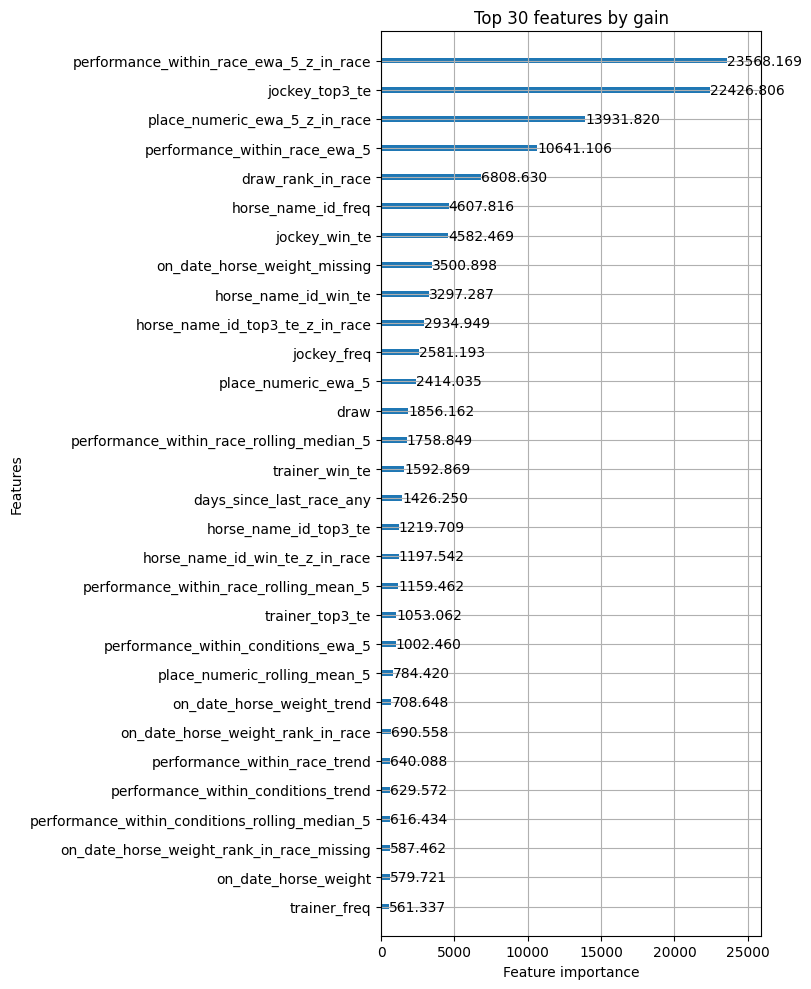

In [12]:
fig, ax = plt.subplots(figsize=(8, 10))
lgb.plot_importance(
    ranker, ax=ax, max_num_features=30,
    importance_type='gain', title='Top 30 features by gain',
)
plt.tight_layout()
plt.show()

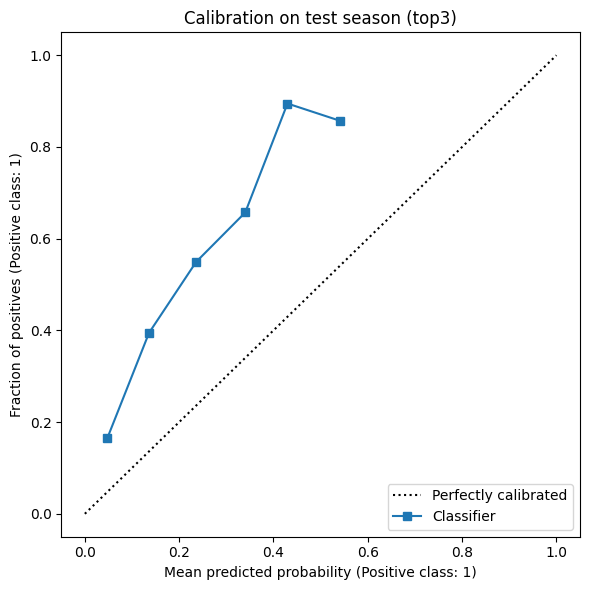

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(
    y_test, test_probs, n_bins=10, ax=ax,
)
ax.set_title(f'Calibration on test season ({TARGET})')
plt.tight_layout()
plt.show()